In [15]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Consistent style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries loaded successfully!")


Libraries loaded successfully!


---
## **1. Stochastic Differential Equation**

The Ornstein-Uhlenbeck process $(X_t)_{t \geq 0}$ is defined as the unique strong solution to the **linear SDE**:

$$dX_t = \theta (\mu - X_t) \, dt + \sigma \, dW_t, \quad X_0 = x_0$$

where:

| Parameter | Role | Constraint |
|-----------|------|------------|
| $\mu$ | Long-term mean | $\mu \in \mathbb{R}$ |
| $\theta > 0$ | Speed of mean reversion | $\theta > 0$ |
| $\sigma > 0$ | Volatility parameter | $\sigma > 0$ |
| $W_t$ | Standard Brownian motion | — |

### Interpretation

- **Drift term** $\theta(\mu - X_t)$: pulls the process toward $\mu$ with strength proportional to the deviation
- **Diffusion term** $\sigma \, dW_t$: injects Gaussian noise

When $X_t > \mu$, the drift is negative (pulls down). When $X_t < \mu$, the drift is positive (pulls up). This creates the characteristic **mean-reverting** behavior.


---
## **2. Explicit Solution**

Applying Ito's lemma to $Y_t = e^{\theta t} X_t$ yields the explicit solution:

$$X_t = \mu + (x_0 - \mu) e^{-\theta t} + \sigma \int_0^t e^{-\theta(t-s)} \, dW_s$$

The stochastic integral is a Wiener integral, so it is Gaussian. Therefore:

$$X_t \sim \mathcal{N}\!\left( \mu + (x_0 - \mu) e^{-\theta t}, \; \frac{\sigma^2}{2\theta}\left(1 - e^{-2\theta t}\right) \right)$$

### Key Observations

1. **Mean:** $\mathbb{E}[X_t] = \mu + (x_0 - \mu) e^{-\theta t} \to \mu$ as $t \to \infty$
2. **Variance:** $\text{Var}(X_t) = \frac{\sigma^2}{2\theta}(1 - e^{-2\theta t}) \to \frac{\sigma^2}{2\theta}$ as $t \to \infty$
3. **The process is Gaussian at all times** — a remarkable property
4. 

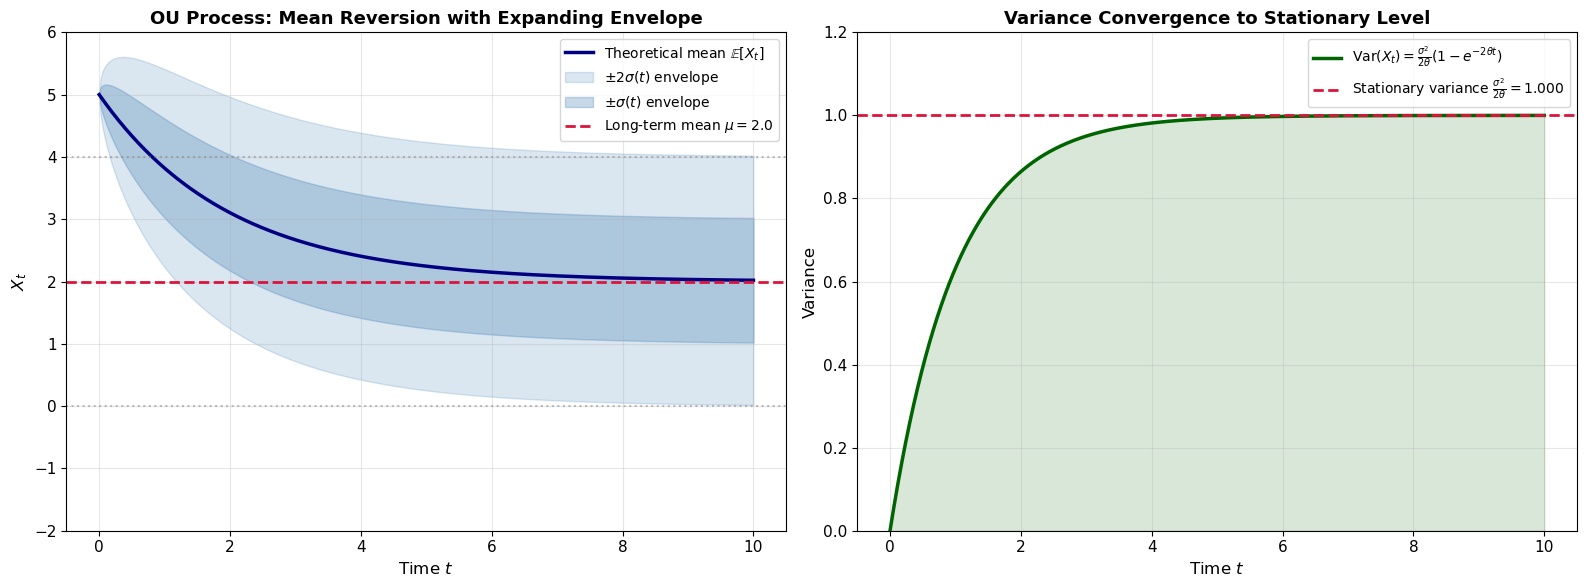

Stationary variance: 1.0000
Stationary standard deviation: 1.0000
Half-life of mean reversion: 1.386


In [16]:
# ============================================================
# 3. Mean, Variance, and Covariance (Theory Curves)
# ============================================================

np.random.seed(42)

# Parameters
mu = 2.0
theta = 0.5
sigma = 1.0
x0 = 5.0  # Start far from mean

T = 10.0
t = np.linspace(0, T, 500)

# Theoretical mean
mean_t = mu + (x0 - mu) * np.exp(-theta * t)

# Theoretical variance
var_t = (sigma**2 / (2 * theta)) * (1 - np.exp(-2 * theta * t))
std_t = np.sqrt(var_t)

# Stationary variance
stationary_var = sigma**2 / (2 * theta)
stationary_std = np.sqrt(stationary_var)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Mean trajectory with confidence bands ---
ax = axes[0]
ax.plot(t, mean_t, 'navy', linewidth=2.5, label=r'Theoretical mean $\mathbb{E}[X_t]$')
ax.fill_between(t, mean_t - 2*std_t, mean_t + 2*std_t, alpha=0.2, color='steelblue',
                label=r'$\pm 2\sigma(t)$ envelope')
ax.fill_between(t, mean_t - std_t, mean_t + std_t, alpha=0.3, color='steelblue',
                label=r'$\pm \sigma(t)$ envelope')
ax.axhline(y=mu, color='crimson', linestyle='--', linewidth=2, label=rf'Long-term mean $\mu = {mu}$')
ax.axhline(y=mu + 2*stationary_std, color='gray', linestyle=':', alpha=0.5)
ax.axhline(y=mu - 2*stationary_std, color='gray', linestyle=':', alpha=0.5)

ax.set_title('OU Process: Mean Reversion with Expanding Envelope', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=12)
ax.set_ylabel('$X_t$', fontsize=12)
ax.legend(fontsize=10, loc='best')
ax.set_ylim(mu - 4*stationary_std, x0 + 1)

# --- Right: Variance convergence ---
ax = axes[1]
ax.plot(t, var_t, 'darkgreen', linewidth=2.5, label=r'$\text{Var}(X_t) = \frac{\sigma^2}{2\theta}(1-e^{-2\theta t})$')
ax.axhline(y=stationary_var, color='crimson', linestyle='--', linewidth=2,
           label=rf'Stationary variance $\frac{{\sigma^2}}{{2\theta}} = {stationary_var:.3f}$')
ax.fill_between(t, 0, var_t, alpha=0.15, color='darkgreen')

ax.set_title('Variance Convergence to Stationary Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=12)
ax.set_ylabel('Variance', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, stationary_var * 1.2)

plt.tight_layout()
plt.show()

print(f"Stationary variance: {stationary_var:.4f}")
print(f"Stationary standard deviation: {stationary_std:.4f}")
print(f"Half-life of mean reversion: {np.log(2)/theta:.3f}")


---
## **4. Stationary Distribution**

As $t \to \infty$, the transient effects decay and the process converges in distribution:

$$X_t \xrightarrow{d} X_\infty \sim \mathcal{N}\!\left(\mu, \frac{\sigma^2}{2\theta}\right)$$

This is the **stationary distribution** (or invariant measure) of the OU process. It is the unique probability distribution $\pi$ satisfying:

$$\int_{-\infty}^{\infty} p_t(x, y) \, \pi(x) \, dx = \pi(y) \quad \text{for all } t > 0$$

where $p_t(x, y)$ is the transition density:

$$p_t(x, y) = \sqrt{\frac{\theta}{\pi \sigma^2 (1 - e^{-2\theta t})}} \exp\!\left( -\frac{\theta (y - \mu - (x-\mu)e^{-\theta t})^2}{\sigma^2 (1 - e^{-2\theta t})} \right)$$

The stationary distribution is **independent of the initial condition** $x_0$.


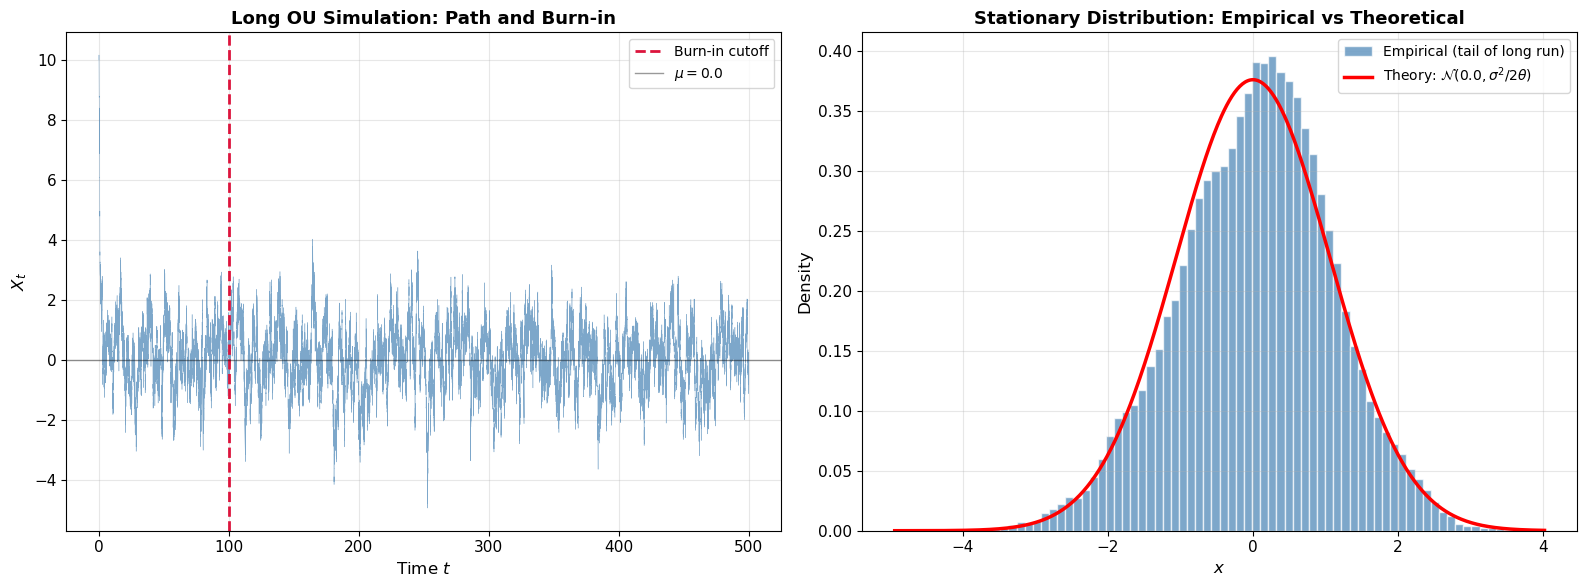

Empirical mean (stationary): 0.0273 (theory: 0.0)
Empirical variance (stationary): 1.1567 (theory: 1.1250)


In [17]:
# ============================================================
# Stationary Distribution: Histogram from Long Simulation
# ============================================================

np.random.seed(2024)

def simulate_ou_euler(x0, mu, theta, sigma, T, N):
    """Simulate OU process via Euler-Maruyama."""
    dt = T / N
    t = np.linspace(0, T, N + 1)
    X = np.zeros(N + 1)
    X[0] = x0
    
    for i in range(N):
        dW = np.random.normal(0, np.sqrt(dt))
        X[i+1] = X[i] + theta * (mu - X[i]) * dt + sigma * dW
    
    return t, X


# Simulate a very long path and take the tail as "stationary"
mu, theta, sigma = 0.0, 1.0, 1.5
x0 = 10.0
T_total = 500.0
N_total = 200000

t, X = simulate_ou_euler(x0, mu, theta, sigma, T_total, N_total)

# Discard burn-in (first 20%)
burn = int(0.2 * N_total)
X_stationary = X[burn:]

# Theoretical stationary PDF
sigma_stat = sigma / np.sqrt(2 * theta)
x_pdf = np.linspace(X_stationary.min(), X_stationary.max(), 500)
pdf_theory = (1.0 / (sigma_stat * np.sqrt(2 * np.pi))) * np.exp(-(x_pdf - mu)**2 / (2 * sigma_stat**2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Full trajectory with burn-in marked ---
ax = axes[0]
ax.plot(t, X, color='steelblue', linewidth=0.3, alpha=0.7)
ax.axvline(x=t[burn], color='crimson', linestyle='--', linewidth=2, label='Burn-in cutoff')
ax.axhline(y=mu, color='black', linestyle='-', linewidth=1, alpha=0.4, label=rf'$\mu = {mu}$')
ax.set_title('Long OU Simulation: Path and Burn-in', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=12)
ax.set_ylabel('$X_t$', fontsize=12)
ax.legend(fontsize=10)

# --- Right: Histogram vs theoretical stationary PDF ---
ax = axes[1]
counts, bins, patches = ax.hist(X_stationary, bins=80, density=True, color='steelblue',
                                 edgecolor='white', alpha=0.7, label='Empirical (tail of long run)')
ax.plot(x_pdf, pdf_theory, 'r-', linewidth=2.5, label=rf'Theory: $\mathcal{{N}}({mu}, \sigma^2/2\theta)$')

ax.set_title('Stationary Distribution: Empirical vs Theoretical', fontsize=13, fontweight='bold')
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"Empirical mean (stationary): {np.mean(X_stationary):.4f} (theory: {mu})")
print(f"Empirical variance (stationary): {np.var(X_stationary):.4f} (theory: {sigma**2/(2*theta):.4f})")


---
## **5. Autocorrelation Function**

For the OU process, the **autocovariance function** is:

$$\text{Cov}(X_s, X_t) = \frac{\sigma^2}{2\theta} e^{-\theta |t-s|} \left(1 - e^{-2\theta \min(s,t)}\right)$$

In the stationary regime ($s, t \to \infty$ with fixed lag $\tau = |t-s|$):

$$\text{Cov}(X_t, X_{t+\tau}) = \frac{\sigma^2}{2\theta} e^{-\theta \tau}$$

Thus the **autocorrelation function** is a simple exponential decay:

$$\rho(\tau) = \frac{\text{Cov}(X_t, X_{t+\tau})}{\text{Var}(X_t)} = e^{-\theta \tau}$$

### Interpretation

- At lag $\tau = 0$: perfect correlation $\rho(0) = 1$
- At lag $\tau = 1/\theta$: correlation drops to $e^{-1} \approx 0.368$
- At lag $\tau \to \infty$: decorrelation $\rho(\tau) \to 0$

The parameter $\theta$ directly controls the **memory** of the process: larger $\theta$ means faster decay of correlation.


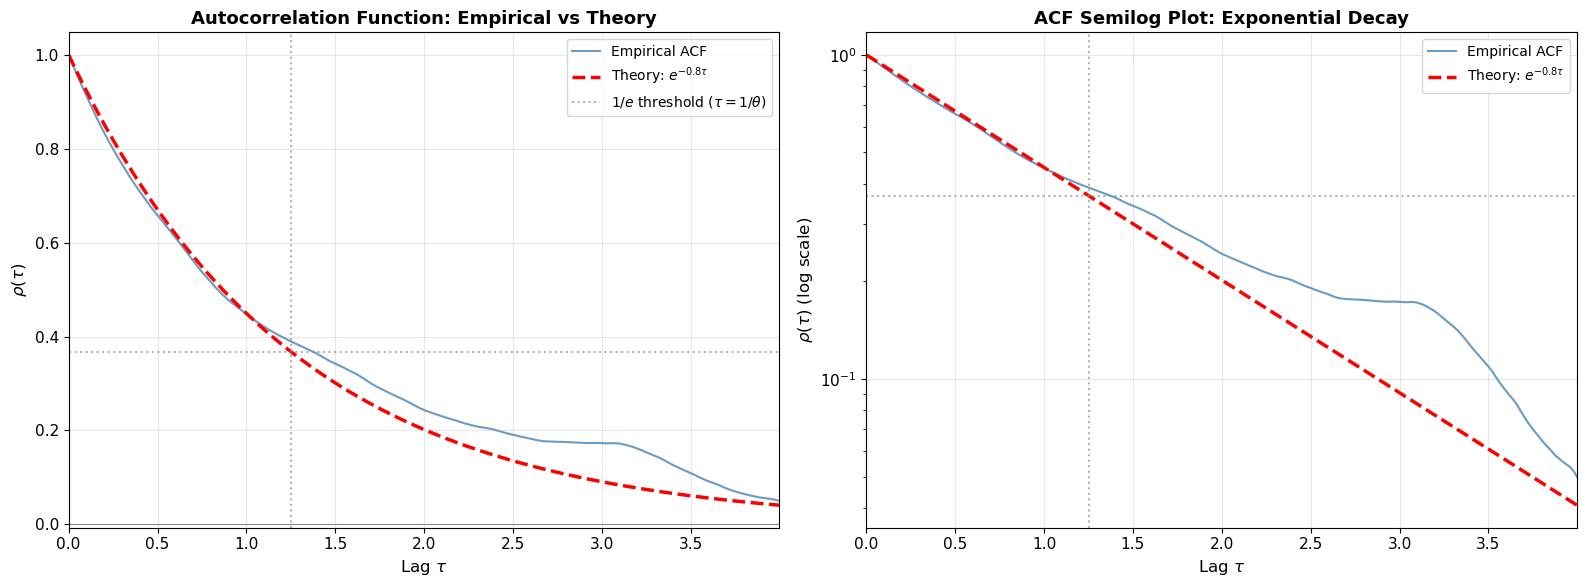

Theoretical correlation time (1/theta): 1.250
Empirical correlation at tau=1/theta: 0.3897


In [23]:
# ============================================================
# Autocorrelation: Theory vs Empirical from Simulation
# ============================================================

np.random.seed(77)

mu, theta, sigma = 0.0, 0.8, 1.0
x0 = mu
T = 200.0
N = 100000
dt = T / N

t, X = simulate_ou_euler(x0, mu, theta, sigma, T, N)


def empirical_acf(x, max_lag=None):
    """Compute autocorrelation function via FFT."""
    n = len(x)
    if max_lag is None:
        max_lag = n // 4
    x_centered = x - np.mean(x)
    f = np.fft.fft(x_centered, n=2 * n)
    acov = np.real(np.fft.ifft(f * np.conj(f)))[:n]
    acov = acov / n
    acf = acov / acov[0]
    return acf[:max_lag]


max_lag = 2000
lags = np.arange(max_lag) * dt
acf_emp = empirical_acf(X, max_lag=max_lag)

# Theoretical ACF
acf_theory = np.exp(-theta * lags)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: ACF comparison ---
ax = axes[0]
ax.plot(lags, acf_emp, color='steelblue', linewidth=1.5, alpha=0.8, label='Empirical ACF')
ax.plot(lags, acf_theory, 'r--', linewidth=2.5, label=rf'Theory: $e^{{-{theta}\tau}}$')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.4)
ax.axhline(y=np.exp(-1), color='gray', linestyle=':', linewidth=1.5, alpha=0.6,
           label=rf'$1/e$ threshold ($\tau = 1/\theta$)')
ax.axvline(x=1.0 / theta, color='gray', linestyle=':', linewidth=1.5, alpha=0.6)

ax.set_title('Autocorrelation Function: Empirical vs Theory', fontsize=13, fontweight='bold')
ax.set_xlabel(r'Lag $\tau$', fontsize=12)
ax.set_ylabel(r'$\rho(\tau)$', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(0, lags[-1])

# --- Right: Semilog plot to show exponential decay ---
ax = axes[1]
# Clip tiny negatives that can appear from numerical noise
acf_emp_clipped = np.clip(acf_emp, 1e-6, None)
ax.semilogy(lags, acf_emp_clipped, color='steelblue', linewidth=1.5, alpha=0.8, label='Empirical ACF')
ax.semilogy(lags, acf_theory, 'r--', linewidth=2.5, label=rf'Theory: $e^{{-{theta}\tau}}$')
ax.axhline(y=np.exp(-1), color='gray', linestyle=':', linewidth=1.5, alpha=0.6)
ax.axvline(x=1.0 / theta, color='gray', linestyle=':', linewidth=1.5, alpha=0.6)

ax.set_title('ACF Semilog Plot: Exponential Decay', fontsize=13, fontweight='bold')
ax.set_xlabel(r'Lag $\tau$', fontsize=12)
ax.set_ylabel(r'$\rho(\tau)$ (log scale)', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(0, lags[-1])

plt.tight_layout()
plt.show()

print(f"Theoretical correlation time (1/theta): {1/theta:.3f}")
lag_idx = int(round(1.0 / (theta * dt)))
if lag_idx < len(acf_emp):
    print(f"Empirical correlation at tau=1/theta: {acf_emp[lag_idx]:.4f}")
else:
    print(f"Lag index {lag_idx} out of bounds (max lag = {len(acf_emp)-1})")


---
## **6. Euler-Maruyama Simulation**

For general SDEs, exact simulation is impossible. The **Euler-Maruyama scheme** provides a simple approximation:

$$X_{t_{i+1}} = X_{t_i} + \theta(\mu - X_{t_i}) \Delta t + \sigma \sqrt{\Delta t} \, Z_i, \quad Z_i \sim \mathcal{N}(0,1)$$

For the OU process, we can also simulate **exactly** from the conditional distribution:

$$X_{t+\Delta t} \mid X_t \sim \mathcal{N}\!\left( \mu + (X_t - \mu)e^{-\theta \Delta t}, \; \frac{\sigma^2}{2\theta}(1 - e^{-2\theta \Delta t}) \right)$$

This exact scheme is exact in distribution (no discretization error) and is preferred when possible.


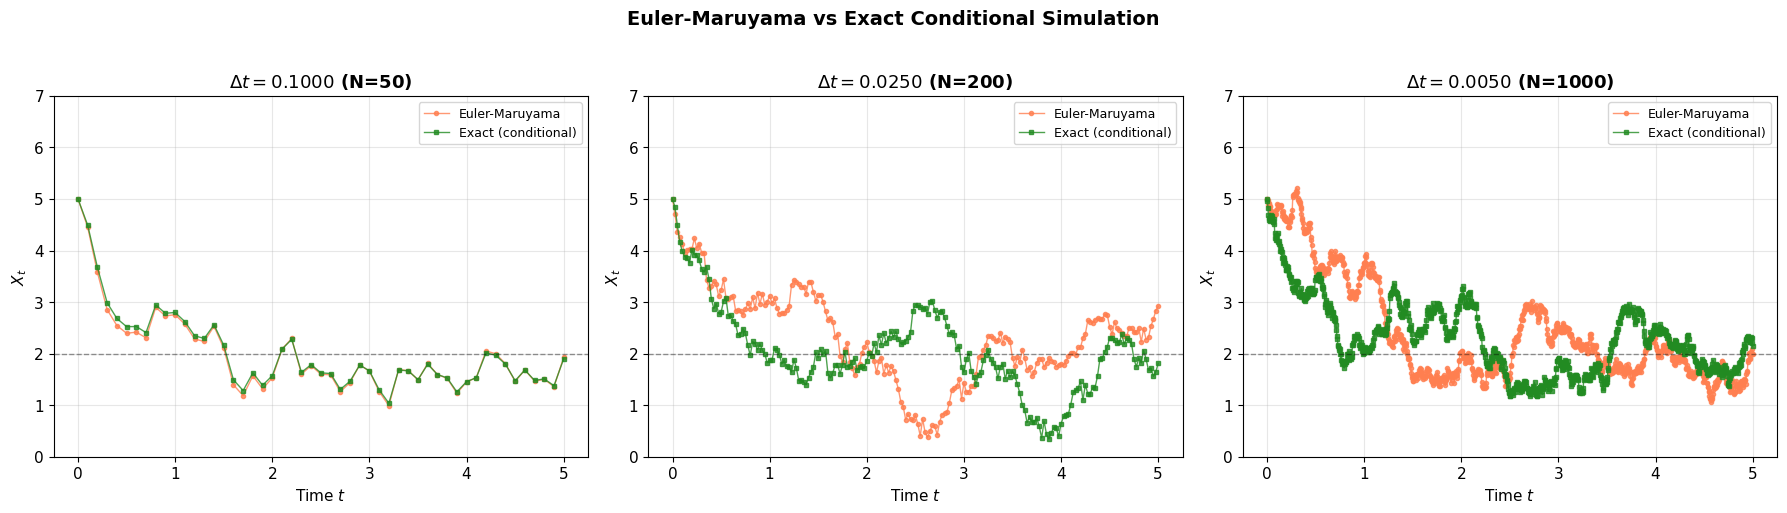

Euler-Maruyama discretization error (RMSE vs exact at T=5):
  N=   50, dt=0.10000: RMSE = 0.03644
  N=  100, dt=0.05000: RMSE = 0.01507
  N=  200, dt=0.02500: RMSE = 0.00714
  N=  500, dt=0.01000: RMSE = 0.00294
  N= 1000, dt=0.00500: RMSE = 0.00146
  N= 5000, dt=0.00100: RMSE = 0.00032


In [24]:
# ============================================================
# Euler-Maruyama vs Exact Simulation
# ============================================================

np.random.seed(33)

mu, theta, sigma = 2.0, 1.5, 1.0
x0 = 5.0
T = 5.0

# Different step sizes
N_values = [50, 200, 1000]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, N in enumerate(N_values):
    dt = T / N
    t = np.linspace(0, T, N + 1)
    
    # --- Euler-Maruyama ---
    X_euler = np.zeros(N + 1)
    X_euler[0] = x0
    for i in range(N):
        dW = np.random.normal(0, np.sqrt(dt))
        X_euler[i+1] = X_euler[i] + theta * (mu - X_euler[i]) * dt + sigma * dW
    
    # --- Exact simulation (same random seed for fair comparison) ---
    np.random.seed(33)  # Reset for exact
    X_exact = np.zeros(N + 1)
    X_exact[0] = x0
    
    mean_factor = np.exp(-theta * dt)
    var_exact = (sigma**2 / (2 * theta)) * (1 - np.exp(-2 * theta * dt))
    std_exact = np.sqrt(var_exact)
    
    for i in range(N):
        Z = np.random.normal(0, 1)
        X_exact[i+1] = mu + (X_exact[i] - mu) * mean_factor + std_exact * Z
    
    # Plot
    ax = axes[idx]
    ax.plot(t, X_euler, 'o-', color='coral', markersize=3, linewidth=1,
            alpha=0.8, label='Euler-Maruyama')
    ax.plot(t, X_exact, 's-', color='forestgreen', markersize=3, linewidth=1,
            alpha=0.8, label='Exact (conditional)')
    ax.axhline(y=mu, color='black', linestyle='--', linewidth=1, alpha=0.4)
    
    ax.set_title(rf'$\Delta t = {dt:.4f}$ (N={N})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Time $t$', fontsize=11)
    ax.set_ylabel('$X_t$', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 7)

plt.suptitle('Euler-Maruyama vs Exact Conditional Simulation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Error analysis ---
print("Euler-Maruyama discretization error (RMSE vs exact at T=5):")
for N in [50, 100, 200, 500, 1000, 5000]:
    dt = T / N
    errors = []
    for trial in range(100):
        # Euler
        X_e = x0
        np.random.seed(trial)
        for i in range(N):
            dW = np.random.normal(0, np.sqrt(dt))
            X_e = X_e + theta * (mu - X_e) * dt + sigma * dW
        
        # Exact
        X_ex = x0
        np.random.seed(trial)
        var_step = (sigma**2 / (2 * theta)) * (1 - np.exp(-2 * theta * dt))
        std_step = np.sqrt(var_step)
        for i in range(N):
            Z = np.random.normal(0, 1)
            X_ex = mu + (X_ex - mu) * np.exp(-theta * dt) + std_step * Z
        
        errors.append((X_e - X_ex)**2)
    
    rmse = np.sqrt(np.mean(errors))
    print(f"  N={N:5d}, dt={dt:.5f}: RMSE = {rmse:.5f}")


---
## **7. Parameter Sensitivity**

The three parameters $(\theta, \mu, \sigma)$ control distinct aspects of the OU process:

| Parameter | Effect on paths |
|-----------|-----------------|
| $\mu$ | Vertical center of oscillation |
| $\theta$ | Speed of mean reversion (steepness of pull) |
| $\sigma$ | Amplitude of fluctuations |

### Varying $\theta$ (speed of reversion)

Larger $\theta$ means:
- Faster decay of the transient mean $(x_0 - \mu)e^{-\theta t}$
- Smaller stationary variance $\sigma^2 / (2\theta)$
- Shorter correlation time $1/\theta$

### Varying $\sigma$ (volatility)

Larger $\sigma$ means:
- Wider envelope of fluctuations
- Larger stationary variance
- Same mean reversion speed
- 

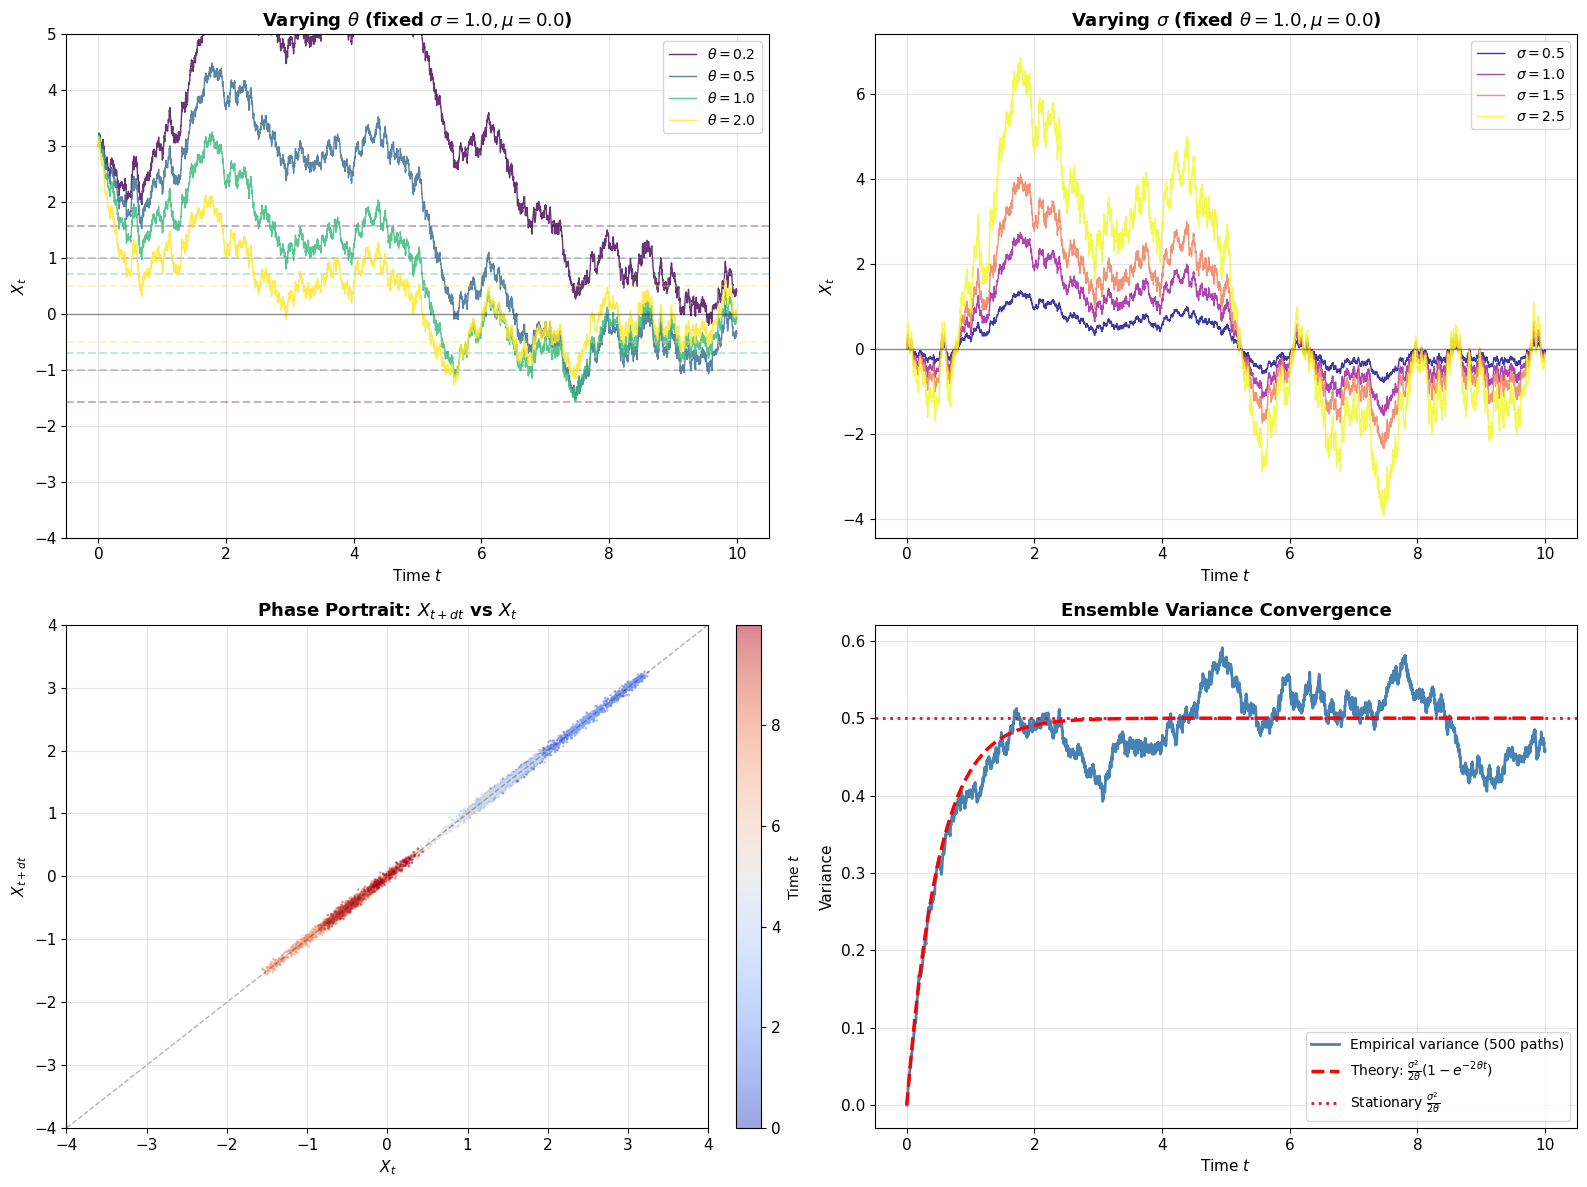

In [20]:
# ============================================================
# Parameter Sensitivity: Varying theta and sigma
# ============================================================

np.random.seed(88)

mu = 0.0
T = 10.0
N = 5000
dt = T / N
t = np.linspace(0, T, N + 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Top Left: Varying theta, fixed sigma ---
ax = axes[0, 0]
sigma = 1.0
x0 = 3.0
theta_values = [0.2, 0.5, 1.0, 2.0]
colors = plt.cm.viridis(np.linspace(0, 1, len(theta_values)))

for th, color in zip(theta_values, colors):
    X = np.zeros(N + 1)
    X[0] = x0
    np.random.seed(88)
    for i in range(N):
        dW = np.random.normal(0, np.sqrt(dt))
        X[i+1] = X[i] + th * (mu - X[i]) * dt + sigma * dW
    ax.plot(t, X, color=color, linewidth=1, alpha=0.8, label=rf'$\theta = {th}$')
    ax.axhline(y=mu + sigma/np.sqrt(2*th), color=color, linestyle='--', alpha=0.3)
    ax.axhline(y=mu - sigma/np.sqrt(2*th), color=color, linestyle='--', alpha=0.3)

ax.axhline(y=mu, color='black', linestyle='-', linewidth=1, alpha=0.4)
ax.set_title(rf'Varying $\theta$ (fixed $\sigma={sigma}, \mu={mu}$)', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('$X_t$', fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(-4, 5)

# --- Top Right: Varying sigma, fixed theta ---
ax = axes[0, 1]
theta = 1.0
x0 = 0.0
sigma_values = [0.5, 1.0, 1.5, 2.5]
colors = plt.cm.plasma(np.linspace(0, 1, len(sigma_values)))

for sig, color in zip(sigma_values, colors):
    X = np.zeros(N + 1)
    X[0] = x0
    np.random.seed(88)
    for i in range(N):
        dW = np.random.normal(0, np.sqrt(dt))
        X[i+1] = X[i] + theta * (mu - X[i]) * dt + sig * dW
    ax.plot(t, X, color=color, linewidth=1, alpha=0.8, label=rf'$\sigma = {sig}$')

ax.axhline(y=mu, color='black', linestyle='-', linewidth=1, alpha=0.4)
ax.set_title(rf'Varying $\sigma$ (fixed $\theta={theta}, \mu={mu}$)', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('$X_t$', fontsize=11)
ax.legend(fontsize=10)

# --- Bottom Left: Phase portrait (X_t vs X_{t+dt}) ---
ax = axes[1, 0]
theta = 1.0
sigma = 1.0
np.random.seed(88)
X = np.zeros(N + 1)
X[0] = 3.0
for i in range(N):
    dW = np.random.normal(0, np.sqrt(dt))
    X[i+1] = X[i] + theta * (mu - X[i]) * dt + sigma * dW

ax.scatter(X[:-1], X[1:], c=t[:-1], cmap='coolwarm', s=1, alpha=0.5)
ax.plot([-4, 4], [-4, 4], 'k--', linewidth=1, alpha=0.3, label='$X_{t+dt} = X_t$')
ax.set_title('Phase Portrait: $X_{t+dt}$ vs $X_t$', fontsize=13, fontweight='bold')
ax.set_xlabel('$X_t$', fontsize=11)
ax.set_ylabel('$X_{t+dt}$', fontsize=11)
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
cbar = plt.colorbar(ax.collections[0], ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Time $t$', fontsize=10)

# --- Bottom Right: Ensemble variance over time ---
ax = axes[1, 1]
theta = 1.0
sigma = 1.0
n_ensemble = 500
variance_trajectories = np.zeros((n_ensemble, N + 1))

for j in range(n_ensemble):
    X = np.zeros(N + 1)
    X[0] = 3.0
    for i in range(N):
        dW = np.random.normal(0, np.sqrt(dt))
        X[i+1] = X[i] + theta * (mu - X[i]) * dt + sigma * dW
    variance_trajectories[j, :] = X

empirical_var = np.var(variance_trajectories, axis=0)
theory_var = (sigma**2 / (2 * theta)) * (1 - np.exp(-2 * theta * t)) + (3.0**2) * np.exp(-2 * theta * t) - (3.0 * np.exp(-theta * t))**2
# Actually correct: Var(X_t) from explicit solution starting at x0
# Var = sigma^2/(2theta)(1 - e^{-2theta t}) since deterministic initial condition
theory_var = (sigma**2 / (2 * theta)) * (1 - np.exp(-2 * theta * t))

ax.plot(t, empirical_var, color='steelblue', linewidth=2, label='Empirical variance (500 paths)')
ax.plot(t, theory_var, 'r--', linewidth=2.5, label=rf'Theory: $\frac{{\sigma^2}}{{2\theta}}(1-e^{{-2\theta t}})$')
ax.axhline(y=sigma**2/(2*theta), color='crimson', linestyle=':', linewidth=2,
           label=rf'Stationary $\frac{{\sigma^2}}{{2\theta}}$')

ax.set_title('Ensemble Variance Convergence', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('Variance', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


---
## **8. Paths to Stationarity**

Starting far from equilibrium ($x_0 \neq \mu$), the OU process exhibits two regimes:

1. **Transient regime** ($t \ll 1/\theta$): deterministic decay dominates
   $$X_t \approx \mu + (x_0 - \mu)e^{-\theta t} + \text{small noise}$$

2. **Stationary regime** ($t \gg 1/\theta$): fluctuations around $\mu$ with constant variance
   $$X_t \approx \mu + \mathcal{N}\!\left(0, \frac{\sigma^2}{2\theta}\right)$$

The **relaxation time** $1/\theta$ separates these two regimes.


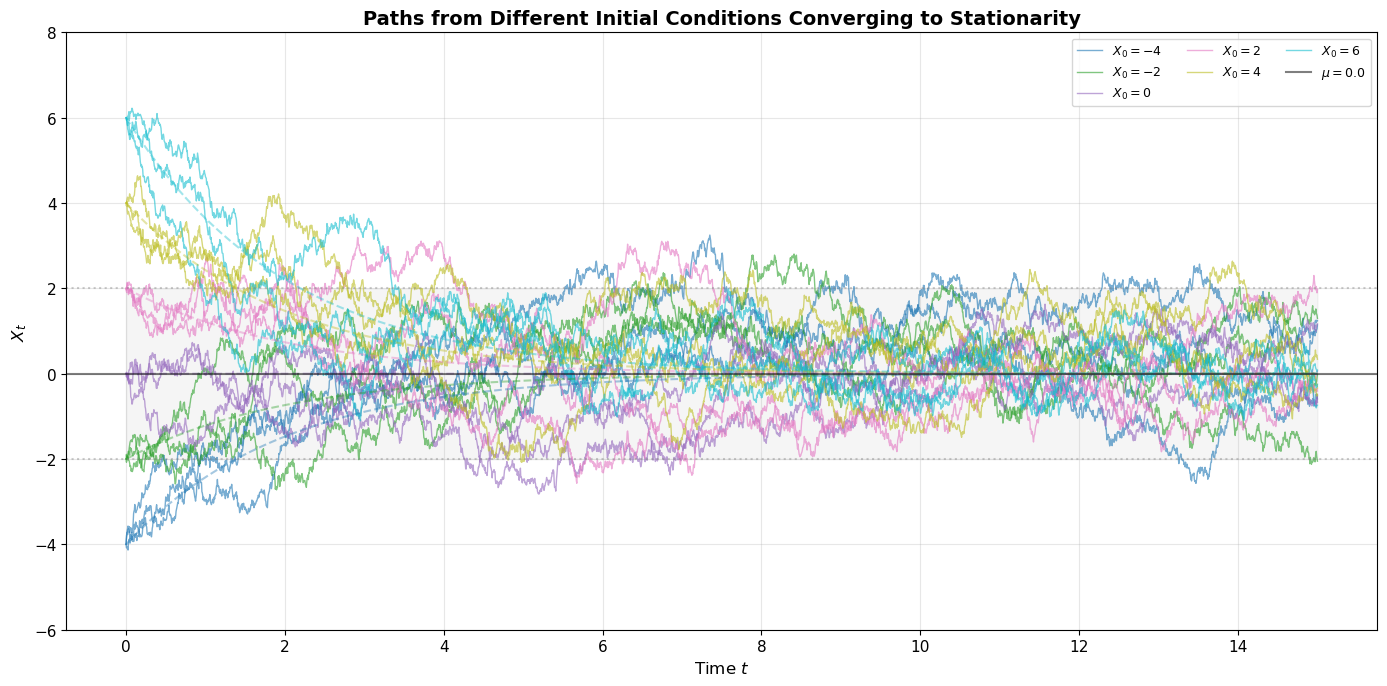

In [21]:
# ============================================================
# Transient vs Stationary: Multiple Initial Conditions
# ============================================================

np.random.seed(101)

mu, theta, sigma = 0.0, 0.5, 1.0
T = 15.0
N = 3000
dt = T / N
t = np.linspace(0, T, N + 1)

x0_values = [-4, -2, 0, 2, 4, 6]
n_paths_per_x0 = 3

fig, ax = plt.subplots(figsize=(14, 7))

colors = plt.cm.tab10(np.linspace(0, 1, len(x0_values)))

for idx_x0, x0 in enumerate(x0_values):
    color = colors[idx_x0]
    for p in range(n_paths_per_x0):
        X = np.zeros(N + 1)
        X[0] = x0
        np.random.seed(101 + idx_x0 * 10 + p)
        for i in range(N):
            dW = np.random.normal(0, np.sqrt(dt))
            X[i+1] = X[i] + theta * (mu - X[i]) * dt + sigma * dW
        
        label = rf'$X_0 = {x0}$' if p == 0 else ''
        ax.plot(t, X, color=color, linewidth=1, alpha=0.6, label=label)

# Theoretical mean envelope
mean_env = mu + (np.array(x0_values)[:, None] - mu) * np.exp(-theta * t[None, :])
for idx, x0 in enumerate(x0_values):
    ax.plot(t, mean_env[idx], '--', color=colors[idx], linewidth=1.5, alpha=0.4)

ax.axhline(y=mu, color='black', linestyle='-', linewidth=1.5, alpha=0.5, label=rf'$\mu = {mu}$')
stationary_std = sigma / np.sqrt(2 * theta)
ax.axhline(y=mu + 2*stationary_std, color='gray', linestyle=':', alpha=0.4)
ax.axhline(y=mu - 2*stationary_std, color='gray', linestyle=':', alpha=0.4)
ax.fill_between(t, mu - 2*stationary_std, mu + 2*stationary_std, alpha=0.08, color='gray')

ax.set_title('Paths from Different Initial Conditions Converging to Stationarity',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=12)
ax.set_ylabel('$X_t$', fontsize=12)
ax.legend(fontsize=9, ncol=3, loc='upper right')
ax.set_ylim(-6, 8)

plt.tight_layout()
plt.show()


---
## **9. Applications**

### Physics: Langevin Equation

The OU process describes the **velocity** $V_t$ of a Brownian particle under friction:

$$m \, dV_t = -\gamma V_t \, dt + \sqrt{2\gamma k_B T} \, dW_t$$

This is an OU process with $\theta = \gamma/m$, $\mu = 0$, and $\sigma = \sqrt{2\gamma k_B T}/m$.

### Finance: Vasicek Model

The **Vasicek interest rate model** assumes the short rate $r_t$ follows:

$$dr_t = a(b - r_t) \, dt + \sigma \, dW_t$$

where $b$ is the long-run mean rate and $a$ the speed of adjustment. The model allows negative rates — a limitation addressed by the **Cox-Ingersoll-Ross (CIR)** model.

### Signal Processing: Colored Noise

OU noise is **red noise** with power spectral density:

$$S(f) = \frac{\sigma^2}{\theta^2 + (2\pi f)^2}$$

Unlike white noise (flat spectrum), it suppresses high frequencies.


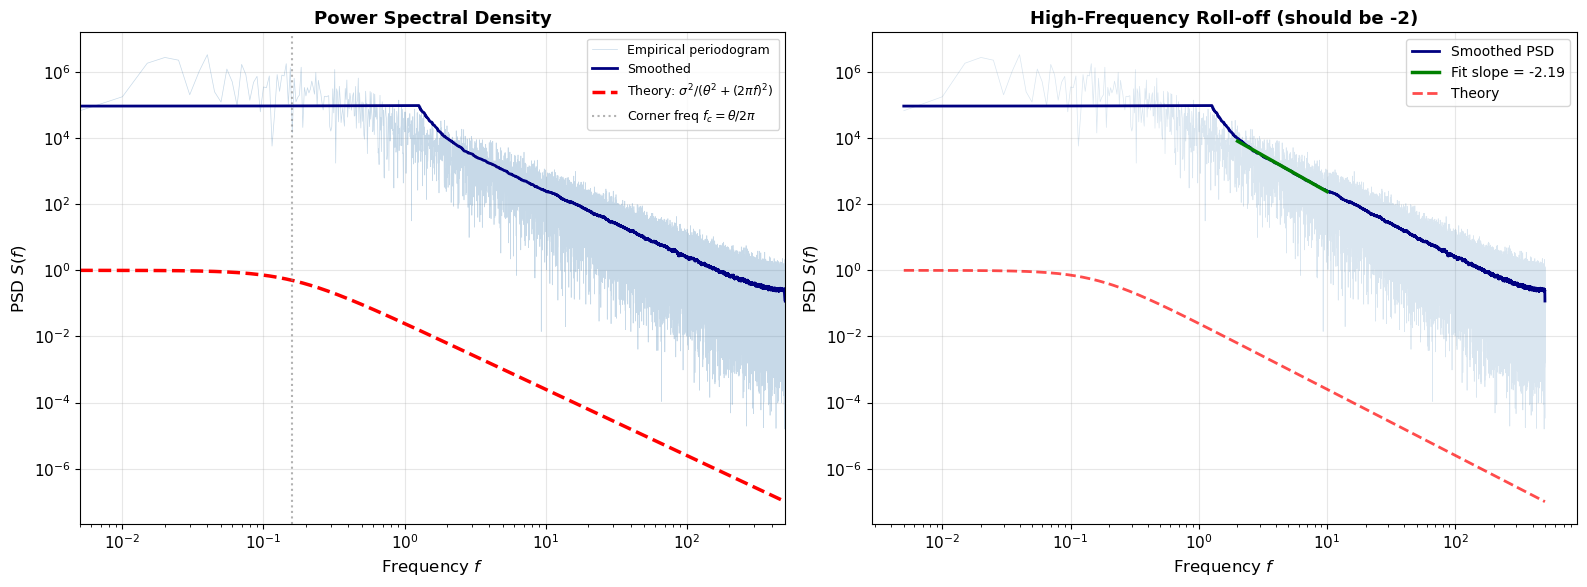

Theoretical corner frequency: 0.1592
Empirical slope at high frequencies: -2.187 (theory: -2.0)


In [25]:
# ============================================================
# Power Spectral Density of OU Process
# ============================================================

np.random.seed(55)

mu, theta, sigma = 0.0, 1.0, 1.0
T = 200.0
N = 200000
dt = T / N

# Simulate long stationary path
t, X = simulate_ou_euler(mu, mu, theta, sigma, T, N)

# Compute periodogram
freqs = np.fft.rfftfreq(len(X), d=dt)
psd_emp = (np.abs(np.fft.rfft(X - np.mean(X)))**2) / (len(X) * dt)

# Theoretical PSD: S(f) = sigma^2 / (theta^2 + (2*pi*f)^2)
psd_theory = (sigma**2) / (theta**2 + (2 * np.pi * freqs)**2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Linear scale ---
ax = axes[0]
# Avoid log(0) by masking zero frequency
mask_pos = freqs > 0
ax.loglog(freqs[mask_pos], psd_emp[mask_pos], color='steelblue', alpha=0.3, linewidth=0.5, label='Empirical periodogram')

# Smooth the periodogram
window = 500
smoothed = np.convolve(psd_emp, np.ones(window) / window, mode='same')
ax.loglog(freqs[mask_pos], smoothed[mask_pos], color='navy', linewidth=2, label='Smoothed')
ax.loglog(freqs[mask_pos], psd_theory[mask_pos], 'r--', linewidth=2.5, label=rf'Theory: $\sigma^2 / (\theta^2 + (2\pi f)^2)$')

ax.axvline(x=theta / (2 * np.pi), color='gray', linestyle=':', linewidth=1.5, alpha=0.6,
           label=rf'Corner freq $f_c = \theta/2\pi$')
ax.set_title('Power Spectral Density', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency $f$', fontsize=12)
ax.set_ylabel('PSD $S(f)$', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(freqs[1], freqs[-1])

# --- Right: Roll-off slope verification ---
ax = axes[1]
ax.loglog(freqs[mask_pos], psd_emp[mask_pos], color='steelblue', alpha=0.2, linewidth=0.5)
ax.loglog(freqs[mask_pos], smoothed[mask_pos], color='navy', linewidth=2, label='Smoothed PSD')

# Fit slope in high-frequency region
mask_fit = (freqs > 2 * theta) & (freqs < 10 * theta) & (smoothed > 0)
slope = None
if np.sum(mask_fit) > 10:
    slope, intercept = np.polyfit(np.log10(freqs[mask_fit]), np.log10(smoothed[mask_fit]), 1)
    ax.loglog(freqs[mask_fit], 10**intercept * freqs[mask_fit]**slope, 'g-', linewidth=2.5,
              label=rf'Fit slope = {slope:.2f}')

ax.loglog(freqs[mask_pos], psd_theory[mask_pos], 'r--', linewidth=2, alpha=0.7, label='Theory')
ax.set_title('High-Frequency Roll-off (should be -2)', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency $f$', fontsize=12)
ax.set_ylabel('PSD $S(f)$', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"Theoretical corner frequency: {theta/(2*np.pi):.4f}")
if slope is not None:
    print(f"Empirical slope at high frequencies: {slope:.3f} (theory: -2.0)")
else:
    print("Could not compute slope (insufficient data in fitting region)")


---
## **10. Summary**

| Property | Formula |
|----------|---------|
| **SDE** | $dX_t = \theta(\mu - X_t)dt + \sigma dW_t$ |
| **Solution** | $X_t = \mu + (x_0 - \mu)e^{-\theta t} + \sigma \int_0^t e^{-\theta(t-s)} dW_s$ |
| **Mean** | $\mathbb{E}[X_t] = \mu + (x_0 - \mu)e^{-\theta t}$ |
| **Variance** | $\text{Var}(X_t) = \frac{\sigma^2}{2\theta}(1 - e^{-2\theta t})$ |
| **Stationary** | $\mathcal{N}(\mu, \sigma^2/2\theta)$ |
| **ACF** | $\rho(\tau) = e^{-\theta \tau}$ |
| **PSD** | $S(f) = \sigma^2 / (\theta^2 + 4\pi^2 f^2)$ |

### References

1. **Oksendal, B.** (2003). *Stochastic Differential Equations* (6th ed.). Springer.
2. **Gardiner, C.W.** (2009). *Stochastic Methods: A Handbook for the Natural and Social Sciences* (4th ed.). Springer.
3. **Vasicek, O.** (1977). "An Equilibrium Characterization of the Term Structure." *Journal of Financial Economics*, 5(2), 177-188.
4. **Uhlenbeck, G.E. & Ornstein, L.S.** (1930). "On the Theory of the Brownian Motion." *Physical Review*, 36(5), 823.


